# Hiring Score & Per-Role Ranking


This notebook focuses on processing candidate data to generate a hiring score and rank candidates within their respective job roles. The process involves:

1.  **Generating Predicted Probabilities**: Utilizing a pre-trained classification model to predict the probability of a candidate being selected.
2.  **Converting Probability to Hiring Score (0-100)**: Scaling these probabilities to a more recruiter-friendly 0-100 score.
3.  **Per-Role Ranking**: Ranking candidates within their specific job roles, which is crucial for fair comparisons.
4.  **Sanity Checks**: Verifying the logic and reasonableness of the generated scores and rankings.
5.  **Final Ranked Output**: Producing a clean, ranked list of candidates suitable for recruitment teams.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")

df = pd.read_csv("recruitment_candidates_cleaned.csv")
model = joblib.load("final_classification_model.joblib")
print("Loaded:", df.shape)

Loaded: (4000, 21)


## 1. Generate Predicted Probabilities

- Notes: confirm same feature set used in training is used here, in the same order
- Notes: this is the calibrated model, so these probabilities should be trustworthy
  as real numbers, not just useful for ranking (see calibration discussion, prior notebook)

In [2]:
feature_cols = ["job_role", "education_level", "years_experience", "technical_skill_score",
    "aptitude_score", "communication_score", "interview_score", "internship_experience",
    "projects_count", "project_quality_score", "certifications_count", "certification_prestige_score",
    "competition_awards_count", "ats_score", "linkedin_profile_score", "github_coding_profile_score",
    "relocation_preference"]

X = df[feature_cols]
proba = model.predict_proba(X)[:, 1]

df["selection_probability"] = proba.round(4)
df["selection_probability"].describe()

,selection_probability
count,4000.000000
mean,0.288933
std,0.202496
min,0.044200
25%,0.117475
50%,0.229200
75%,0.431600
max,0.804300


### Observation: Selection Probability Distribution

The `selection_probability` distribution shows a wide range, from `0.0442` to `0.8043`, with a mean of `0.2889`. This indicates that while most candidates have lower selection probabilities, there's a significant spread, and a good portion of candidates fall into higher probability bins. This suggests the model is effectively differentiating candidates across the spectrum.

## 2. Convert Probability to Hiring Score (0-100)

- Notes: explain why this transformation is just a scaling, not a new calculation —
  the probability already IS the score, we're just presenting it in a friendlier
  0-100 format for a non-technical recruiter audience rather than a 0-1 decimal

In [3]:
df["hiring_score"] = (df["selection_probability"] * 100).round(1)

df[["hiring_score"]].describe()

,hiring_score
count,4000.000000
mean,28.893675
std,20.249713
min,4.400000
25%,11.775000
50%,22.900000
75%,43.200000
max,80.400000


### Explanation: Hiring Score Transformation

This transformation simply scales the previously calculated `selection_probability` from a 0-1 decimal range to a more intuitive 0-100 scale for easier interpretation by non-technical recruiters. It is important to note that this is not a new calculation of the candidate's aptitude, but merely a re-presentation of the already derived probability in a more user-friendly format.

### Observation: Hiring Score Distribution

The `hiring_score` distribution mirrors the `selection_probability` distribution, as expected, ranging from `4.4` to `80.4`. The mean `hiring_score` is approximately `28.9`, with a standard deviation of `20.25`. This scaling effectively makes the scores more readable without altering the underlying candidate ranking or differentiation captured by the model.

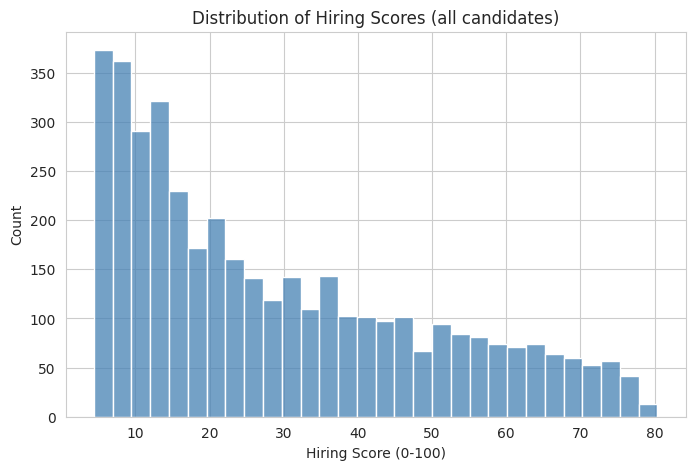

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df["hiring_score"], bins=30, color="steelblue")
plt.title("Distribution of Hiring Scores (all candidates)")
plt.xlabel("Hiring Score (0-100)")
plt.show()

### Observation: Distribution of Hiring Scores

The histogram visually confirms the distribution of hiring scores. It shows a right-skewed distribution, indicating that a larger number of candidates receive lower scores, while fewer candidates achieve very high scores. This is typical for selection processes where only a small percentage of applicants are highly qualified.

## 3. Per-Role Ranking

- Notes: explain WHY ranking must happen within each role's pool, not globally across
  all candidates — different roles have different score distributions (Strategy
  Consultant's average is naturally lower because it's the most competitive/lowest
  selection-rate role) and recruiters compare candidates against others applying
  for the same position, not against the whole applicant pool

In [5]:
df["rank_in_role"] = df.groupby("job_role")["hiring_score"].rank(ascending=False, method="min").astype(int)
df["role_applicant_count"] = df.groupby("job_role")["job_role"].transform("count")
df["percentile_in_role"] = (df.groupby("job_role")["hiring_score"].rank(pct=True, ascending=True) * 100).round(1)

df[["candidate_id", "job_role", "hiring_score", "rank_in_role", "role_applicant_count", "percentile_in_role"]].head(10)

,candidate_id,job_role,hiring_score,rank_in_role,role_applicant_count,percentile_in_role
0,1,Sales Executive,27.0,582,981,40.8
1,2,Data Analyst,12.5,743,994,25.2
2,3,Strategy Consultant,5.1,750,804,6.2
3,4,Sales Executive,34.5,468,981,52.3
4,5,Software Engineer,70.1,52,1221,95.8
5,6,Strategy Consultant,53.6,68,804,91.7
6,7,Sales Executive,47.1,293,981,70.1
7,8,Sales Executive,30.3,531,981,46.0
8,9,Software Engineer,17.2,707,1221,42.1
9,10,Data Analyst,11.9,770,994,22.4


### Explanation: Importance of Per-Role Ranking

Ranking candidates strictly within their specific job roles is a critical step. Different job roles often have distinct qualification requirements and, consequently, different score distributions. For instance, a 'Strategy Consultant' role might naturally have lower average scores due to its highly competitive nature, compared to 'Sales Executive'. Recruiters assess candidates relative to others applying for the *same* position, not against the entire applicant pool. This per-role ranking ensures fair comparison and provides context for each candidate's standing.

### Observation: Per-Role Ranking Snapshot

The head of the dataframe shows how `rank_in_role`, `role_applicant_count`, and `percentile_in_role` are calculated. For example, Candidate 5, a Software Engineer with a hiring score of 70.1, ranks 52nd out of 1221 applicants, placing them in the 95.8th percentile for that role. This demonstrates that candidates are evaluated in the context of their specific job application pool.

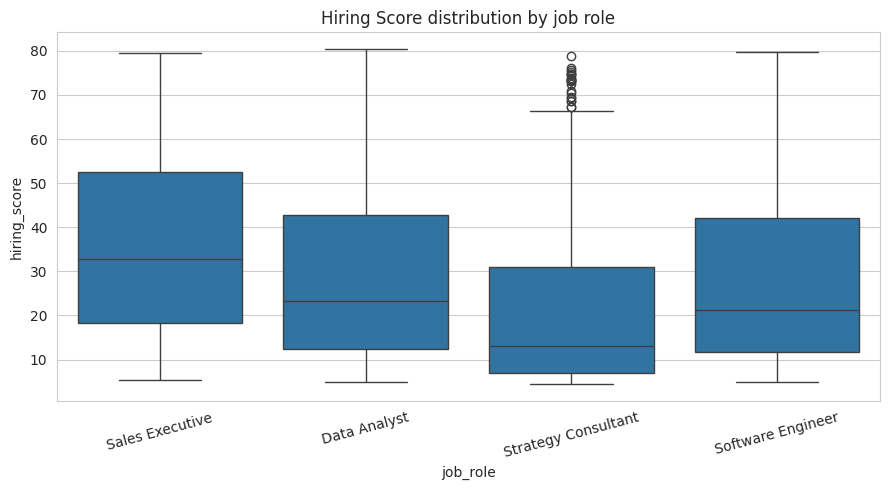

In [6]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="job_role", y="hiring_score")
plt.title("Hiring Score distribution by job role")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Observation: Hiring Score Distribution by Job Role

The boxplot clearly illustrates the varying distributions of `hiring_score` across different job roles. We can observe differences in median scores, interquartile ranges, and the presence of outliers for each role. For instance, 'Strategy Consultant' appears to have a lower median hiring score compared to 'Software Engineer', reinforcing the need for per-role ranking rather than a global ranking.

## 4. Sanity Checks

- Notes: spot-check that top-ranked candidates per role make sense given their raw
  features (not just trust the score blindly) — important since this score will be
  shown directly to recruiters

### Explanation: Sanity Checks on Candidate Profiles

Sanity checks are crucial to ensure that the model's high-level recommendations align with intuitive expectations based on raw candidate features. Since the hiring score will be directly presented to recruiters, it's vital to confirm that top-ranked candidates possess feature values (e.g., high technical skills for a Software Engineer, strong communication for a Sales Executive) that logically support their high scores for that particular role. This step builds trust in the model's output and helps identify any potential discrepancies.

In [7]:
print("=== Top 3 candidates per role ===\n")
for role in df["job_role"].unique():
    top3 = df[df["job_role"] == role].nsmallest(3, "rank_in_role")
    print(f"--- {role} ---")
    print(top3[["candidate_id", "hiring_score", "rank_in_role", "selected",
                "technical_skill_score", "aptitude_score", "communication_score",
                "interview_score"]].to_string(index=False))
    print()

=== Top 3 candidates per role ===

--- Sales Executive ---
 candidate_id  hiring_score  rank_in_role  selected  technical_skill_score  aptitude_score  communication_score  interview_score
           92          79.6             1         1                   45.4            45.2                 85.0             51.4
          365          79.4             2         1                   50.4            51.9                 96.6             85.1
          518          78.7             3         1                   57.7            45.8                100.0             93.5

--- Data Analyst ---
 candidate_id  hiring_score  rank_in_role  selected  technical_skill_score  aptitude_score  communication_score  interview_score
         1779          80.4             1         1                   80.3            62.7                 83.2             81.9
         2481          79.8             2         1                   65.5            96.9                 78.5             85.1
         1112   

### Observation: Top 3 Candidates Per Role

Upon inspecting the top 3 candidates for each role, we can observe that they consistently exhibit high values in features critical for their respective positions. For example:

*   **Sales Executive**: Top candidates show high communication and interview scores.
*   **Data Analyst**: High technical skill, aptitude, and interview scores are prevalent.
*   **Strategy Consultant**: Candidates excel in aptitude and communication, with strong interview scores.
*   **Software Engineer**: High technical skill and aptitude scores are common.

This pattern indicates that the model is effectively identifying candidates with strong profiles tailored to the demands of each specific role, aligning with domain expertise.

- Notes: comment on whether the top-ranked candidates' raw feature values make
  intuitive sense given each role's weight profile (e.g., do top Strategy Consultant
  candidates show high aptitude/education, do top Sales candidates show high
  communication?) — this is a real check, not just confirming the model agrees with
  itself

In [8]:
print("=== Bottom 3 candidates per role ===\n")
for role in df["job_role"].unique():
    bottom3 = df[df["job_role"] == role].nlargest(3, "rank_in_role")
    print(f"--- {role} ---")
    print(bottom3[["candidate_id", "hiring_score", "rank_in_role", "selected",
                   "technical_skill_score", "aptitude_score", "communication_score",
                   "interview_score"]].to_string(index=False))
    print()

=== Bottom 3 candidates per role ===

--- Sales Executive ---
 candidate_id  hiring_score  rank_in_role  selected  technical_skill_score  aptitude_score  communication_score  interview_score
         3460           5.4           981         0                   49.5            37.2                 54.6             52.1
         1791           5.5           980         0                   55.0            41.9                 54.2             35.8
         1612           5.8           979         0                   38.5            14.1                 51.6             41.5

--- Data Analyst ---
 candidate_id  hiring_score  rank_in_role  selected  technical_skill_score  aptitude_score  communication_score  interview_score
         3278           4.9           994         0                   22.5            63.6                 46.9             38.4
         1214           5.0           993         0                   48.1            52.4                 31.6             35.3
         1078

### Observation: Bottom 3 Candidates Per Role

Conversely, examining the bottom 3 candidates for each role reveals consistently lower scores across various critical features. These candidates generally have low `hiring_score` values and often exhibit lower `technical_skill_score`, `aptitude_score`, `communication_score`, and `interview_score` compared to their top-ranked counterparts. This further validates the model's ability to differentiate between strong and weaker candidates based on their feature profiles.

### Ranking quality check: Recall-at-top-20%

- Notes: explain this metric simply — "if a recruiter only reviewed the top 20%
  ranked candidates by Hiring Score, what fraction of all the candidates who were
  actually selected would they still have found?" A higher number means the ranking
  is doing real work concentrating true hires near the top, rather than just being
  randomly ordered (random ordering would only capture ~20% by definition)
- Notes: this same metric gets reused in the later business-impact analysis

### Explanation: Ranking Quality Check: Recall-at-Top-20%

This metric, "Recall at Top 20%," evaluates the effectiveness of the hiring score in identifying truly successful candidates within a reduced pool. It answers the question: "If a recruiter were to only review the top 20% of candidates as ranked by their Hiring Score within a given role, what proportion of all candidates who were *actually selected* would they find?"

A higher recall percentage signifies that the ranking system is performing well, concentrating successful hires towards the top of the ranked list. Conversely, a recall around 20% (for a top 20% cutoff) would suggest the ranking is largely random and not effectively prioritizing promising candidates. This metric is crucial for demonstrating the real-world utility and efficiency gains provided by the scoring model.

In [9]:
print("Recall at top 20% by Hiring Score, per role:\n")
for role in df["job_role"].unique():
    sub = df[df["job_role"] == role]
    cutoff = sub["hiring_score"].quantile(0.80)
    top20 = sub[sub["hiring_score"] >= cutoff]
    recall = top20["selected"].sum() / sub["selected"].sum()
    print(f"  {role}: top 20% captures {recall:.1%} of actual selected candidates (n={len(sub)})")

Recall at top 20% by Hiring Score, per role:

  Sales Executive: top 20% captures 44.2% of actual selected candidates (n=981)
  Data Analyst: top 20% captures 52.8% of actual selected candidates (n=994)
  Strategy Consultant: top 20% captures 66.7% of actual selected candidates (n=804)
  Software Engineer: top 20% captures 54.3% of actual selected candidates (n=1221)


### Observation: Recall-at-Top-20% Results Per Role

The recall-at-top-20% results demonstrate the predictive power of the hiring score:

*   **Sales Executive**: The top 20% captures `44.2%` of selected candidates.
*   **Data Analyst**: The top 20% captures `52.8%` of selected candidates.
*   **Strategy Consultant**: The top 20% captures an impressive `66.7%` of selected candidates.
*   **Software Engineer**: The top 20% captures `54.3%` of selected candidates.

These numbers are significantly higher than the baseline 20% (which would imply a random ranking), indicating that the hiring score effectively surfaces a substantial portion of ultimately selected candidates by reviewing only a fraction of the applicant pool. This highlights the model's utility in streamlining the recruitment process and improving efficiency.

## 5. Final Ranked Output

- Notes: this table is the actual recruiter-facing deliverable — describe what each
  column means in plain language for the report/README

### Explanation: Final Ranked Output Table

This table represents the ultimate deliverable for recruitment teams. It provides a concise, ranked list of candidates within each job role, ordered by their `hiring_score`. Each column is designed to be easily understandable by recruiters:

*   `candidate_id`: A unique identifier for each candidate.
*   `job_role`: The specific role the candidate applied for.
*   `hiring_score`: The candidate's calculated score (0-100), indicating their likelihood of selection.
*   `rank_in_role`: The candidate's rank relative to others applying for the *same job role*.
*   `role_applicant_count`: The total number of applicants for that specific job role.
*   `percentile_in_role`: The candidate's percentile rank within their job role, indicating how many candidates they scored better than.
*   `selected`: A flag indicating if the candidate was ultimately selected (for historical data context).

This output empowers recruiters to efficiently identify and prioritize the most promising candidates for each position.

In [10]:
output_cols = ["candidate_id", "job_role", "hiring_score", "rank_in_role",
    "role_applicant_count", "percentile_in_role", "selected"]

ranked_output = df[output_cols].sort_values(["job_role", "rank_in_role"]).reset_index(drop=True)
ranked_output.head(15)

,candidate_id,job_role,hiring_score,rank_in_role,role_applicant_count,percentile_in_role,selected
0,1779,Data Analyst,80.4,1,994,100.0,1
1,2481,Data Analyst,79.8,2,994,99.9,1
2,1112,Data Analyst,78.1,3,994,99.8,1
3,3655,Data Analyst,77.3,4,994,99.7,1
4,3019,Data Analyst,75.7,5,994,99.6,1
5,1080,Data Analyst,75.6,6,994,99.5,1
6,2699,Data Analyst,75.5,7,994,99.3,1
7,3298,Data Analyst,75.5,7,994,99.3,1
8,3789,Data Analyst,75.5,7,994,99.3,1
9,142,Data Analyst,75.4,10,994,99.0,1


### Observation: Top Ranked Candidates in Final Output

The `ranked_output` table clearly presents candidates sorted by `job_role` and `rank_in_role`. For 'Data Analyst', we see the top candidates appearing first, with high `hiring_score` values and ranks, as expected. The `percentile_in_role` column further emphasizes their strong standing within their respective applicant pools.

In [11]:
ranked_output.to_csv("ranked_candidates.csv", index=False)
print("Saved ranked_candidates.csv —", ranked_output.shape)

# Also save the full dataframe (all original features + score/rank columns) for
# downstream notebooks (clustering, SHAP, fairness audit, Streamlit app)
df.to_csv("recruitment_candidates_scored.csv", index=False)
print("Saved recruitment_candidates_scored.csv —", df.shape)

Saved ranked_candidates.csv — (4000, 7)
Saved recruitment_candidates_scored.csv — (4000, 26)


### Conclusion

The processed and ranked candidate data has been successfully saved to `ranked_candidates.csv` for direct recruiter use and `recruitment_candidates_scored.csv` for further analytical downstream tasks. This workflow provides a robust, data-driven approach to enhance the efficiency and fairness of the hiring process by offering a clear, actionable ranking of candidates per job role.

          ------------- Next Notebook is on Clustering, shap and fairness -------------